<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Losso_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 14)

Dataset:
   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            No

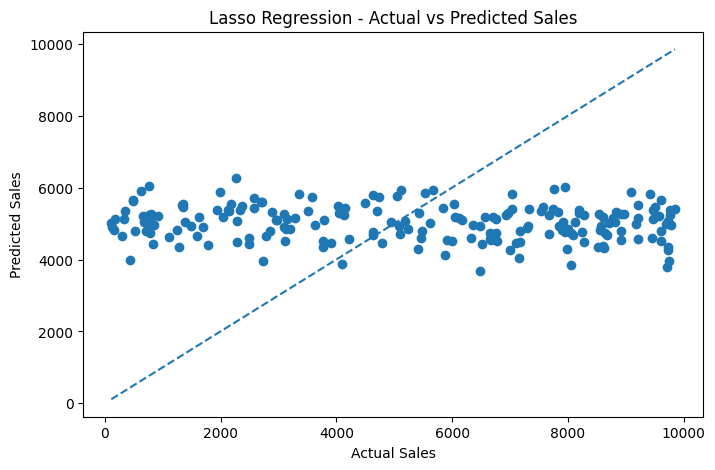

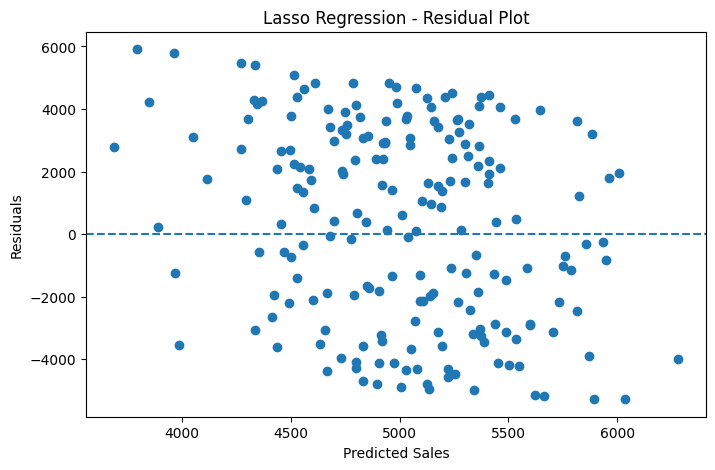

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("sales_data.csv")

print("Dataset Shape:", df.shape)
print("\nDataset:")
print(df.head())


# ==========================================
# 2. REMOVE UNNECESSARY COLUMN
# ==========================================

df = df.drop("Sale_Date", axis=1)


# ==========================================
# 3. DEFINE X AND Y
# ==========================================

X = df.drop("Sales_Amount", axis=1)
y = df["Sales_Amount"]


# ==========================================
# 4. IDENTIFY COLUMNS
# ==========================================

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns


# ==========================================
# 5. PREPROCESSING
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)


# ==========================================
# 6. LASSO REGRESSION MODEL
# ==========================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "lasso",
        Lasso(
            alpha=0.1,
            max_iter=10000
        )
    )
])


# ==========================================
# 7. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ==========================================
# 8. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 9. PREDICTION
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 10. MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)


print("\n===================================")
print("LASSO REGRESSION RESULTS")
print("===================================")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")


# ==========================================
# 11. GRAPH 1
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Lasso Regression - Actual vs Predicted Sales")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()


# ==========================================
# 12. GRAPH 2
# RESIDUAL PLOT
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Lasso Regression - Residual Plot")

plt.show()


